# H1 / H2 / H3 — Statistical Analysis

Reads `data/results.csv` produced by `scripts/run_matrix.py` and tests the three hypotheses from the SRF proposal:

- **H1** — Closed-loop replanning improves coverage (full vs. `no-replan`).
- **H2** — Cross-tool fusion reduces redundancy (full vs. `no-fusion`).
- **H3** — LLM reasoning degrades predictably (per-decision label distribution).

Each test uses a paired t-test on `findings_count` (or `duration_s` for H2 efficiency) keyed on `target`, and reports Cohen's d alongside the p-value. Figures save into `notebooks/figures/` as PNGs for the paper.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_CSV = REPO_ROOT / 'data' / 'results.csv'
FIG_DIR = REPO_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(RESULTS_CSV)
df.head()

,target,condition,engine_set,planner,seed,duration_s,engines_used,engine_count,findings_count,replans,...,high,medium,low,info,decisions_correct,decisions_suboptimal,decisions_incorrect,decisions_total,aborted,error
0,juiceshop,full,real,heuristic,0,0.0938,"http_probe,url_crawler,header_vuln_check",3,12,2,...,0,10,0,2,3,0,2,5,False,NaN
1,juiceshop,no-replan,real,heuristic,0,0.0047,"http_probe,url_crawler",2,2,0,...,0,0,0,2,2,0,0,2,False,NaN
2,juiceshop,no-fusion,real,heuristic,0,0.0637,"http_probe,url_crawler,header_vuln_check",3,12,2,...,0,10,0,2,3,0,2,5,False,NaN
3,juiceshop,random-order,real,heuristic,0,0.0538,"http_probe,url_crawler,header_vuln_check",3,12,2,...,0,10,0,2,3,0,2,5,False,NaN
4,commix_testbed,full,real,heuristic,0,0.0405,"http_probe,url_crawler,header_vuln_check",3,8,2,...,0,3,3,2,3,0,2,5,False,NaN


In [2]:
# Aggregate to one row per (target, condition) by averaging across seeds.
agg = df.groupby(['target', 'condition'], as_index=False).agg({
    'findings_count': 'mean',
    'engine_count':   'mean',
    'replans':        'mean',
    'duration_s':     'mean',
    'decisions_correct':    'mean',
    'decisions_suboptimal': 'mean',
    'decisions_incorrect':  'mean',
    'decisions_total':      'mean',
    'critical': 'mean', 'high': 'mean',
    'medium':   'mean', 'low':  'mean', 'info': 'mean',
})
pivot_findings = agg.pivot(index='target', columns='condition',
                           values='findings_count').dropna()
pivot_findings

condition,full,no-fusion,no-replan,random-order
target,,,,
bwapp,4.75,3.25,2.75,3.750000
commix_testbed,4.25,2.75,2.75,3.250000
crapi,3.00,1.00,3.00,1.666667
dvwa,3.00,1.00,3.00,1.666667
dvws_node,3.00,1.00,3.00,1.666667
htb_lan,9.00,1.00,4.00,3.666667
juiceshop,5.25,3.75,2.75,4.250000
mutillidae,3.00,1.00,3.00,1.666667
vampi,4.00,2.50,2.75,3.000000


## H1 — Closed-loop replanning improves coverage

Paired t-test on `findings_count`: `full` vs. `no-replan`, paired by `target`. Hypothesis predicts `full > no-replan` (one-sided).

In [3]:
def cohens_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) else float('nan')

h1_full = pivot_findings['full']
h1_norep = pivot_findings['no-replan']
t, p = stats.ttest_rel(h1_full, h1_norep, alternative='greater')
d = cohens_d_paired(h1_full, h1_norep)
n = len(h1_full)
print(f'H1 (full > no-replan):  n={n}, t={t:.3f}, p={p:.4f}, Cohen d={d:.3f}')
print(f'  mean(full)      = {h1_full.mean():.2f}')
print(f'  mean(no-replan) = {h1_norep.mean():.2f}')
print(f'  delta           = {(h1_full - h1_norep).mean():+.2f} '
      f'({(h1_full - h1_norep).mean() / max(h1_norep.mean(), 1):+.1%})')

H1 (full > no-replan):  n=11, t=2.950, p=0.0073, Cohen d=0.890
  mean(full)      = 4.73
  mean(no-replan) = 3.07
  delta           = +1.66 (+54.1%)


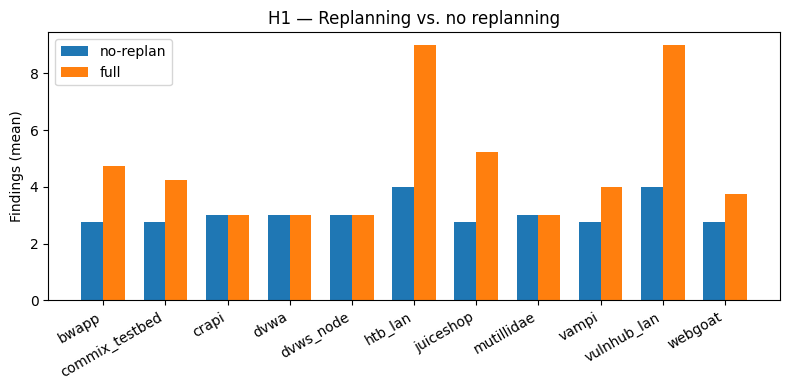

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(h1_full))
w = 0.35
ax.bar(x - w/2, h1_norep.values, w, label='no-replan')
ax.bar(x + w/2, h1_full.values,  w, label='full')
ax.set_xticks(x)
ax.set_xticklabels(h1_full.index, rotation=30, ha='right')
ax.set_ylabel('Findings (mean)')
ax.set_title('H1 — Replanning vs. no replanning')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'h1_findings_full_vs_no_replan.png', dpi=150)
plt.show()

## H2 — Cross-tool fusion improves coverage (and changes time profile)

Paired t-test on `findings_count`: `full` vs. `no-fusion`. Predicted direction: `full > no-fusion` because the downstream engines need upstream facts to produce signal.

In [5]:
h2_full = pivot_findings['full']
h2_nofu = pivot_findings['no-fusion']
t, p = stats.ttest_rel(h2_full, h2_nofu, alternative='greater')
d = cohens_d_paired(h2_full, h2_nofu)
print(f'H2 (full > no-fusion):  n={len(h2_full)}, t={t:.3f}, '
      f'p={p:.4f}, Cohen d={d:.3f}')
print(f'  delta = {(h2_full - h2_nofu).mean():+.2f} findings')

pivot_time = agg.pivot(index='target', columns='condition',
                       values='duration_s').dropna()
tt, tp = stats.ttest_rel(pivot_time['no-fusion'], pivot_time['full'],
                         alternative='greater')
print(f'\nH2 efficiency (no-fusion > full duration_s): '
      f't={tt:.3f}, p={tp:.4f}')

H2 (full > no-fusion):  n=11, t=3.724, p=0.0020, Cohen d=1.123
  delta = +2.86 findings

H2 efficiency (no-fusion > full duration_s): t=-1.973, p=0.9616


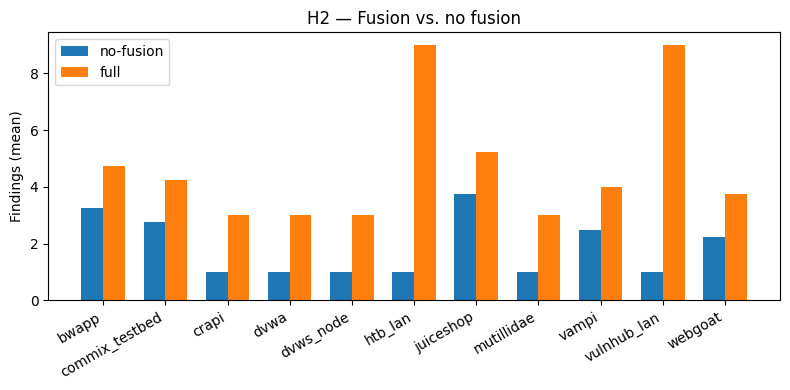

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(h2_full))
ax.bar(x - w/2, h2_nofu.values, w, label='no-fusion')
ax.bar(x + w/2, h2_full.values, w, label='full')
ax.set_xticks(x)
ax.set_xticklabels(h2_full.index, rotation=30, ha='right')
ax.set_ylabel('Findings (mean)')
ax.set_title('H2 — Fusion vs. no fusion')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'h2_findings_full_vs_no_fusion.png', dpi=150)
plt.show()

## H3 — LLM (and heuristic) reasoning degrades predictably

Stacked-bar of decision-label distribution per condition. The annotator labels each pick `correct` / `suboptimal` / `incorrect`. Under ablations, we expect `incorrect` to RISE because the planner emits picks the orchestrator drops (e.g. no-fusion leaves chains broken, so heuristic chain-picks become `dropped_by_orchestrator`).

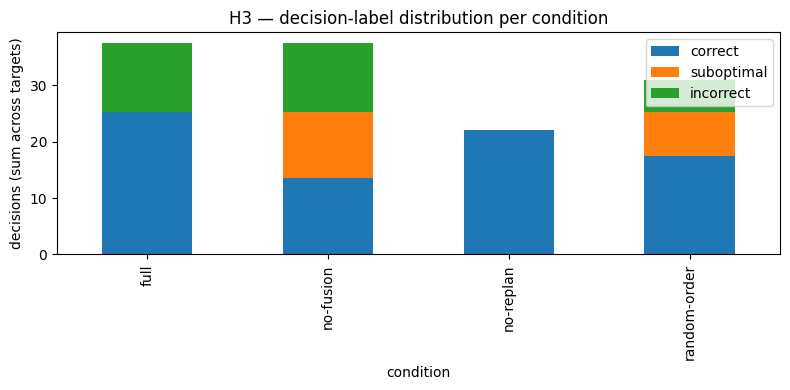

,decisions_correct,decisions_suboptimal,decisions_incorrect
condition,,,
full,25.250000,0.000000,12.25
no-fusion,13.500000,11.750000,12.25
no-replan,22.000000,0.000000,0.00
random-order,17.416667,7.833333,5.75


In [7]:
decisions = agg.groupby('condition', as_index=False).agg({
    'decisions_correct':    'sum',
    'decisions_suboptimal': 'sum',
    'decisions_incorrect':  'sum',
})
decisions = decisions.set_index('condition')

fig, ax = plt.subplots(figsize=(8, 4))
decisions[['decisions_correct', 'decisions_suboptimal',
           'decisions_incorrect']].plot(kind='bar', stacked=True, ax=ax)
ax.set_title('H3 — decision-label distribution per condition')
ax.set_ylabel('decisions (sum across targets)')
ax.legend(['correct', 'suboptimal', 'incorrect'])
fig.tight_layout()
fig.savefig(FIG_DIR / 'h3_decision_quality_stacked.png', dpi=150)
plt.show()
decisions

In [8]:
# Final summary table for the paper.
import io
summary = pd.DataFrame({
    'condition': decisions.index,
    'mean_findings':
        agg.groupby('condition')['findings_count'].mean().reindex(decisions.index).values,
    'mean_duration_s':
        agg.groupby('condition')['duration_s'].mean().reindex(decisions.index).values,
    'pct_incorrect':
        (decisions['decisions_incorrect'] /
         (decisions.sum(axis=1).replace(0, np.nan))).values,
})
print(summary.to_string(index=False))
(REPO_ROOT / 'data' / 'summary.csv').write_text(
    summary.to_csv(index=False)
)

   condition  mean_findings  mean_duration_s  pct_incorrect
        full       4.727273         0.005970       0.326667
   no-fusion       1.863636         0.003861       0.326667
   no-replan       3.068182         0.001220       0.000000
random-order       2.818182         0.003693       0.185484


318